<a href="https://colab.research.google.com/github/yamatai-wizard/GCI_Competition2/blob/test/NFL_Draft_Prediction_ipynb%E3%80%80%E5%AE%9F%E8%A1%8C%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第2回データ分析コンペティション：NFL Draft Prediction

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [47]:
from google.colab import drive,files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc

from xgboost import XGBClassifier

!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [49]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 2. データ読み込み

In [50]:
PATH = '/content/drive/MyDrive/GCI/NFL Draft Prediction/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## 4. 前処理

In [51]:
# prompt: Ageが欠損しているデータはAge欠損の特徴量を与えて

train['Age_nan'] = train['Age'].isnull().astype(int)
test['Age_nan'] = test['Age'].isnull().astype(int)

In [52]:
# prompt: 身体能力テストで欠損値がある場合、欠損の数のフラグが欲しい

physical_test_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle']

# trainデータに対して欠損数フラグを作成
train['physical_test_nan_count'] = train[physical_test_cols].isnull().sum(axis=1)

# testデータに対して欠損数フラグを作成
test['physical_test_nan_count'] = test[physical_test_cols].isnull().sum(axis=1)

In [53]:
# 'kicking_specialist' および 'other_special' 以外のデータでターゲットエンコーディング
non_special_train = train[~train['Position_Type'].isin(['kicking_specialist', 'other_special'])].copy()

# SchoolごとのDraftedの平均値を計算
school_means = non_special_train.groupby('School')['Drafted'].mean()

# Schoolごとの在籍数を計算
school_counts = train['School'].value_counts()

# 在籍数が10以下のSchoolを取得
schools_under_10 = school_counts[school_counts <= 10].index

# 全体の平均値を計算
overall_mean = train['Drafted'].mean()

# Schoolエンコーディング用の辞書を作成
school_encoding = {}
for school, mean_drafted in school_means.items():
    if school in schools_under_10:
        school_encoding[school] = overall_mean
    else:
        school_encoding[school] = mean_drafted

# 訓練データとテストデータにSchoolエンコーディングを適用
train['School_encoded'] = train['School'].map(school_encoding).fillna(overall_mean) # 訓練データにないSchoolは全体の平均値で埋める
test['School_encoded'] = test['School'].map(school_encoding).fillna(overall_mean) # テストデータにないSchoolは全体の平均値で埋める

train.drop(columns=['School'], inplace=True)
test.drop(columns=['School'], inplace=True)

In [54]:
# prompt: trainとtestデータを組み合わせて同Year同Positionごとの 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump’,'Height','Weight'において各Year各ポジションごとのDraft数の中央値を求め上位その値以内に入っている。上位その2倍値以内に入っているという値を特徴量として加えて。また、 'Agility_3cone','Sprint_40yd','Shuttle'については各Year各ポジションごとのDraft数の中央値を求め下位その値以内に入っている。下位その2倍値以内に入っているという値を特徴量として加えて。

import pandas as pd
combined_df = pd.concat([train, test], ignore_index=True)

# Drafted数の中央値の計算（train+testの全体データで実施）
drafted_counts_combined = combined_df.groupby(['Position', 'Year'])['Drafted'].sum().reset_index()

# 各Position各YearごとのDrafted数のAdjusted_Median_Drafted_Countを結合
combined_df = pd.merge(combined_df, median_drafted_by_position_year[['Position', 'Adjusted_Median_Drafted_Count']], on='Position', how='left')

# 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Height', 'Weight'について上位値以内に入っているかのフラグを作成
top_percentile_cols = ['Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Height', 'Weight']

for col in top_percentile_cols:
  # 各Position各Yearごとの値のpercentileを計算
  combined_df[f'{col}_percentile'] = combined_df.groupby(['Position', 'Year'])[col].rank(pct=True, ascending=False)

  # 上位Adjusted_Median_Drafted_Count以内に入っているかのフラグ
  combined_df[f'{col}_top_median_flag'] = (combined_df[f'{col}_percentile'] <= (combined_df['Adjusted_Median_Drafted_Count'] / combined_df.groupby(['Position', 'Year'])[col].transform('count'))).astype(int)

# 'Agility_3cone','Sprint_40yd','Shuttle'について下位値以内に入っているかのフラグを作成
bottom_percentile_cols = ['Agility_3cone','Sprint_40yd','Shuttle']

for col in bottom_percentile_cols:
  # 各Position各Yearごとの値のpercentileを計算 (下位なのでascending=True)
  combined_df[f'{col}_percentile'] = combined_df.groupby(['Position', 'Year'])[col].rank(pct=True, ascending=True)

  # 下位Adjusted_Median_Drafted_Count以内に入っているかのフラグ
  combined_df[f'{col}_bottom_median_flag'] = (combined_df[f'{col}_percentile'] <= (combined_df['Adjusted_Median_Drafted_Count'] / combined_df.groupby(['Position', 'Year'])[col].transform('count'))).astype(int)

# 元のtrainとtestに分割
train = combined_df.iloc[:len(train)].copy()
test = combined_df.iloc[len(train):].copy()

# 作成したPercentile列は不要なので削除
train = train.drop(columns=[f'{col}_percentile' for col in top_percentile_cols + bottom_percentile_cols])
test = test.drop(columns=[f'{col}_percentile' for col in top_percentile_cols + bottom_percentile_cols])

# Adjusted_Median_Drafted_Countも不要なので削除
train = train.drop(columns=['Adjusted_Median_Drafted_Count'])
test = test.drop(columns=['Adjusted_Median_Drafted_Count'])

In [55]:
# prompt: 同Year同Positionごとの'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle','Height','Weight'の偏差値を計算して特徴量にしたい

import pandas as pd
import numpy as np
# 年とPosition_Typeごとの偏差値を計算するための関数
def calculate_standard_scores_by_year_and_position(df, columns):
    df_copy = df.copy()
    for col in columns:
        # YearとPosition_Typeごとに偏差値を計算
        mean_std_by_year_position = df_copy.groupby(['Year', 'Position_Type'])[col].agg(['mean', 'std']).reset_index()
        mean_std_by_year_position.columns = ['Year', 'Position_Type', f'{col}_mean', f'{col}_std']

        # 元のデータフレームに平均値と標準偏差をマージ
        df_copy = pd.merge(df_copy, mean_std_by_year_position, on=['Year', 'Position_Type'], how='left')

        # 偏差値を計算 (標準偏差が0の場合はNaNにならないように0で割らない)
        df_copy[f'{col}_year_pos_std_score'] = (df_copy[col] - df_copy[f'{col}_mean']) / df_copy[f'{col}_std'] * 10 + 50

        # 標準偏差が0の場合は偏差値をNaNにする (元の値がNaNの場合など)
        df_copy[f'{col}_year_pos_std_score'] = df_copy[f'{col}_year_pos_std_score'].fillna(np.nan)

        # 計算に使用した一時列を削除
        df_copy = df_copy.drop(columns=[f'{col}_mean', f'{col}_std'])

    return df_copy

# 偏差値を計算したい列
cols_to_standardize_by_year_pos = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle','Height','Weight']

# 訓練データとテストデータに適用
train = calculate_standard_scores_by_year_and_position(train, cols_to_standardize_by_year_pos)
test = calculate_standard_scores_by_year_and_position(test, cols_to_standardize_by_year_pos)

In [56]:
# prompt: # 各能力値の偏差値が欠損しているものは各ポジションの中央値で欠損値を埋める

# 各能力値の偏差値が欠損しているものは各ポジションの中央値で欠損値を埋める

# 偏差値の列をリスト化
std_score_cols = [f'{col}_year_pos_std_score' for col in cols_to_standardize_by_year_pos]

# 訓練データとテストデータに対して処理を行う
for df in [train, test]:
    for col in std_score_cols:
        # Position_Typeごとの中央値を計算
        median_by_position = df.groupby('Position_Type')[col].transform('median')
        # 欠損値をPosition_Typeごとの中央値で埋める
        df[col] = df[col].fillna(median_by_position)

In [57]:
# 使わない列の削除
train = train.drop(columns=["Id",'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle','Height','Weight','Position_Type', 'Player_Type'])
test = test.drop(columns=["Id",'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle','Height','Weight','Position_Type', 'Player_Type'])

In [58]:
train.isnull().sum()

,0
Year,0
Age,435
Position,0
Drafted,0
Age_nan,0
physical_test_nan_count,0
School_encoded,0
Vertical_Jump_top_median_flag,0
Bench_Press_Reps_top_median_flag,0
Broad_Jump_top_median_flag,0


In [59]:
test.isnull().sum()

,0
Year,0
Age,115
Position,0
Drafted,696
Age_nan,0
physical_test_nan_count,0
School_encoded,0
Vertical_Jump_top_median_flag,0
Bench_Press_Reps_top_median_flag,0
Broad_Jump_top_median_flag,0


In [60]:
# Positionに対するターゲットエンコーディング
# PositionごとのDraftedの平均値を計算
position_means = train.groupby('Position')['Drafted'].mean()

# Positionごとの出現数を計算
position_counts = train['Position'].value_counts()

# 出現数が少ないPositionを取得 (例: 出現数が5以下のPosition)
positions_under_threshold = position_counts[position_counts <= 5].index

# 全体の平均値を計算 (既に計算済み)
# overall_mean = train['Drafted'].mean() # 以前に計算済み

# Positionエンコーディング用の辞書を作成
position_encoding = {}
for position, mean_drafted in position_means.items():
    if position in positions_under_threshold:
        position_encoding[position] = overall_mean # 出現数が少ない場合は全体の平均値で埋める
    else:
        position_encoding[position] = mean_drafted

# 訓練データとテストデータにPositionエンコーディングを適用
train['Position_encoded'] = train['Position'].map(position_encoding).fillna(overall_mean) # 訓練データにないPositionは全体の平均値で埋める
test['Position_encoded'] = test['Position'].map(position_encoding).fillna(overall_mean) # テストデータにないPositionは全体の平均値で埋める

# 元の'Position'列は削除
train.drop(columns=['Position'], inplace=True)
test.drop(columns=['Position'], inplace=True)

## 6. 仮説と特徴量エンジニアリング

In [61]:
train.head()

,Year,Age,Drafted,Age_nan,physical_test_nan_count,School_encoded,Vertical_Jump_top_median_flag,Bench_Press_Reps_top_median_flag,Broad_Jump_top_median_flag,Height_top_median_flag,Weight_top_median_flag,Agility_3cone_bottom_median_flag,Sprint_40yd_bottom_median_flag,Shuttle_bottom_median_flag,Sprint_40yd_year_pos_std_score,Vertical_Jump_year_pos_std_score,Bench_Press_Reps_year_pos_std_score,Broad_Jump_year_pos_std_score,Agility_3cone_year_pos_std_score,Shuttle_year_pos_std_score,Height_year_pos_std_score,Weight_year_pos_std_score,Position_encoded
0,2011,21.0,1.0,0,0,0.648328,0,1,1,0,1,0,0,0,55.949890,31.421337,57.087015,47.982420,53.413658,58.355478,40.789650,47.101036,0.642384
1,2011,24.0,1.0,0,2,0.648328,1,1,1,0,0,0,1,0,34.791944,65.733277,45.138356,70.253652,49.756139,49.837023,46.513428,37.683245,0.594937
2,2018,21.0,1.0,0,0,0.500000,1,0,1,1,1,1,1,1,42.645268,58.794832,35.254813,57.116770,45.851153,53.313371,48.481763,43.456998,0.594937
3,2010,21.0,1.0,0,0,0.461538,1,1,1,1,1,1,1,1,59.044783,43.196231,68.781799,39.579336,73.586779,56.136933,53.637225,69.382252,0.715000
4,2016,21.0,1.0,0,1,0.758621,0,0,0,1,1,1,0,1,50.367660,41.796649,49.365385,37.860318,55.169275,43.621097,51.772775,42.107713,0.594937


In [62]:
test.head()

,Year,Age,Drafted,Age_nan,physical_test_nan_count,School_encoded,Vertical_Jump_top_median_flag,Bench_Press_Reps_top_median_flag,Broad_Jump_top_median_flag,Height_top_median_flag,Weight_top_median_flag,Agility_3cone_bottom_median_flag,Sprint_40yd_bottom_median_flag,Shuttle_bottom_median_flag,Sprint_40yd_year_pos_std_score,Vertical_Jump_year_pos_std_score,Bench_Press_Reps_year_pos_std_score,Broad_Jump_year_pos_std_score,Agility_3cone_year_pos_std_score,Shuttle_year_pos_std_score,Height_year_pos_std_score,Weight_year_pos_std_score,Position_encoded
0,2017,22.0,NaN,0,0,0.666667,1,0,1,1,0,0,0,0,50.000000,61.483167,42.056439,66.015179,65.472880,61.878079,49.423992,41.100745,0.642384
1,2013,22.0,NaN,0,0,0.648328,1,1,1,0,0,1,1,1,43.463689,68.808262,49.654813,64.270791,43.663354,30.856636,32.220867,35.890622,0.692073
2,2018,21.0,NaN,0,1,0.718310,1,0,1,1,1,0,1,1,43.595472,66.101333,47.220212,65.134195,49.661920,54.198766,48.123823,55.087183,0.612000
3,2009,21.0,NaN,0,0,0.777778,1,1,1,1,1,1,1,1,45.566186,53.132890,59.175174,49.600390,43.268780,45.556837,41.607521,50.988423,0.612000
4,2018,23.0,NaN,0,0,0.718310,0,0,1,1,0,1,1,1,38.643505,35.268010,41.701058,45.419432,53.966563,61.598670,48.724105,40.021326,0.692073


In [63]:
X = train.drop(columns=['Drafted'])
y = train['Drafted']

sampler = TPESampler(seed=42)

# Define objective function specifically for XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 1, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    model = XGBClassifier(**params, random_state=42,
                          use_label_encoder=False,
                          eval_metric='logloss',
                          verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc_value = roc_auc_score(y_valid, y_pred_proba)
        auc_scores.append(auc_value)

    return np.mean(auc_scores)

# Optimize only XGBoost
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, n_jobs=1)

best_params = study.best_params
print(f"XGBoost best params: {best_params}")
print(f"Best AUC: {study.best_value:.4f}\n")

[I 2025-07-05 15:21:19,311] A new study created in memory with name: no-name-e8615fbe-4c80-4416-9a3f-394f267d7456
[I 2025-07-05 15:21:34,836] Trial 0 finished with value: 0.8260366835490501 and parameters: {'n_estimators': 218, 'max_depth': 5, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.8260366835490501.
[I 2025-07-05 15:21:47,748] Trial 1 finished with value: 0.8168094922818904 and parameters: {'n_estimators': 440, 'max_depth': 4, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 0 with value: 0.8260366835490501.
[I 2025-07-05 15:21:48,158] Trial 2 finished with value: 0.8216024780357486 and parameters: {'n_estimators': 132, 'max_depth': 1, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119, '

XGBoost best params: {'n_estimators': 467, 'max_depth': 1, 'learning_rate': 0.04265753864010226, 'subsample': 0.9417558873722607, 'colsample_bytree': 0.7563542672385685, 'gamma': 0.47637335563032956, 'min_child_weight': 4}
Best AUC: 0.8450



In [66]:
# Build optimized XGBoost model
optimized_model = XGBClassifier(**best_params, random_state=42,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                verbosity=0)

# Evaluate using stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\n=== XGBoost Evaluation ===')
auc_scores = []
test_pred_proba_list = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f'Fold{fold+1}')

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    optimized_model.fit(X_train, y_train)

    y_valid_pred_proba = optimized_model.predict_proba(X_valid)[:,1]
    auc_value = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc_value)
    print(f'AUC:{round(auc_value,4)}')

    X_test = test.drop(columns=['Drafted'])
    test_pred_proba = optimized_model.predict_proba(X_test)[:,1]
    test_pred_proba_list.append(test_pred_proba)

mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)


=== XGBoost Evaluation ===
Fold1
AUC:0.8345
Fold2
AUC:0.8474
Fold3
AUC:0.875
Fold4
AUC:0.8042
Fold5
AUC:0.864

Average Validation AUC: 0.845


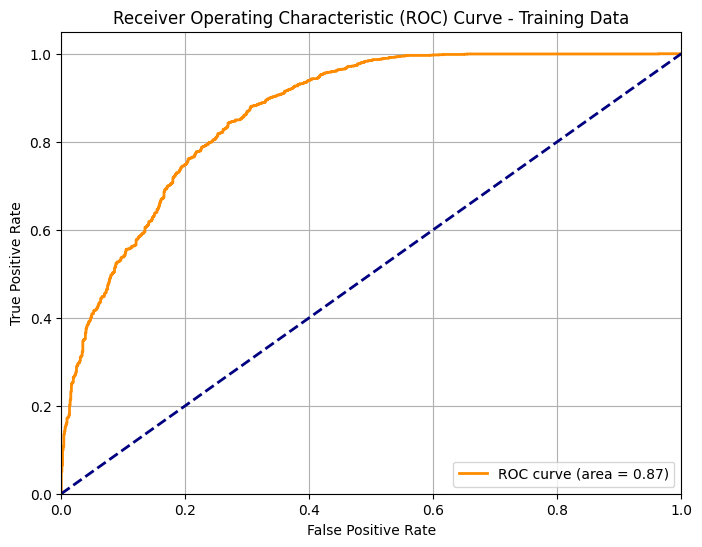

In [67]:
# 訓練データに対するAUCカーブを描写
y_train_pred_proba = optimized_model.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_train_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Training Data')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


=== Feature Importances ===
                                Feature  Importance
2                               Age_nan    0.392861
11       Sprint_40yd_bottom_median_flag    0.155063
1                                   Age    0.134874
21                     Position_encoded    0.032249
4                        School_encoded    0.028643
13       Sprint_40yd_year_pos_std_score    0.027216
18           Shuttle_year_pos_std_score    0.026855
9                Weight_top_median_flag    0.026625
16        Broad_Jump_year_pos_std_score    0.023739
20            Weight_year_pos_std_score    0.020242
17     Agility_3cone_year_pos_std_score    0.019502
8                Height_top_median_flag    0.017645
15  Bench_Press_Reps_year_pos_std_score    0.016110
10     Agility_3cone_bottom_median_flag    0.015858
14     Vertical_Jump_year_pos_std_score    0.015062
3               physical_test_nan_count    0.013340
5         Vertical_Jump_top_median_flag    0.012317
0                                  

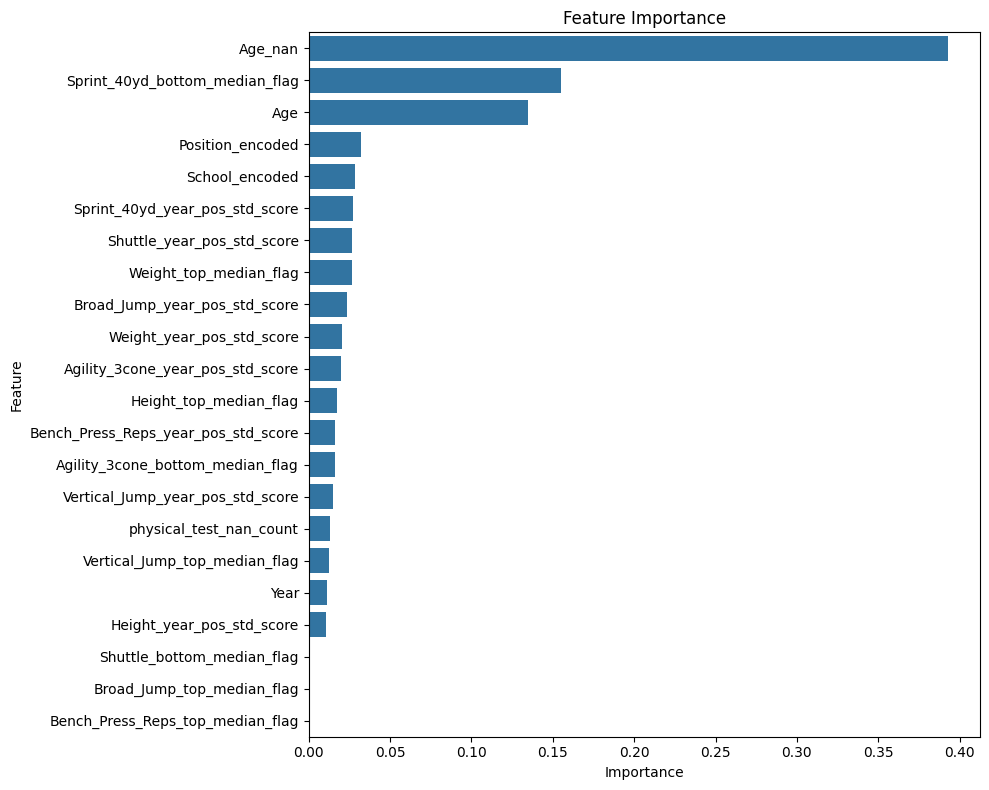

In [68]:
# 特徴量重要度を取得
feature_importances = optimized_model.feature_importances_

# 特徴量名と重要度を組み合わせる
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# 重要度で降順にソート
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 結果を表示
print("\n=== Feature Importances ===")
print(importance_df)

# 特徴量重要度を可視化 (オプション)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [69]:
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'submission.csv', index=False)

files.download(PATH + 'submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 今後の展望

　本ノートブックでは、データの前処理から特徴量エンジニアリング、モデル構築、評価まで、ベースラインモデルの構築を行いました。

　今後はこのベースラインを土台として、さらに高度な特徴量の工夫やアルゴリズムの改善などによって精度向上を目指していくことができます。例えば、以下のような工夫が考えられます。

- カテゴリデータのエンコーディング手法の変更
- 欠損値の補完手法の変更
- 別のモデルの検討
- モデルのハイパーパラメータ調整
- 特徴量エンジニアリング


　高スコア獲得を目指して、頑張りましょう！